<div style="background-color: #FCE8E6; padding: 10px; border-radius: 5px;">

# CSAI3121 - Machine Learning and Intelligent Data Analysis
## Lab 3 - Logistic Regression

#### Student name: _Liao Tian_____________________________

#### Student ID: __P2421086______________________________

**Assessment: 20 points total**  

- Practical implementation and result presentation: 7 points
- Conceptual multiple-choice assessment: 10 points
- Submitted on-time: 3 points
  
Use the supplied `Default.csv` file. Complete the code cells and answer the questions at the end.

**Submission:** 
- Rename this file to "lab3_your_student_ID.ipynb" e.g., lab3_P2201234.ipynb
- Fill in the GenAI file
- Submit both files to Canvas


<div style="background-color: #f0f8ff; padding: 10px; border-radius: 5px;">

### Learning objectives

By the end of the lab, you should be able to:

- fit a binary logistic-regression classifier;
- distinguish class predictions from predicted probabilities;
- interpret a logistic probability curve and decision threshold;
- calculate and interpret accuracy, F1, MCC, and confusion matrix;
- explain why a baseline with high accuracy may still be poor for detecting defaults.

</div>

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 1. Load and inspect the data


Load `Default.csv` into a DataFrame called `df`, then display the first five rows.

**Hint:** use `pd.read_csv(...)` and `.head()`.


In [39]:
# Your code:

df = pd.read_csv("Default.csv")
df.head()


,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


Use `df.info()` to inspect the columns. Display the category counts for both `default` and `student`.

**Hint:** use `.value_counts()` on each categorical column. Do not use `df.value_counts()` for this task.


In [40]:
# Your code:
df.info()

print("\n")
print("Category counts:")
print(df['default'].value_counts(), '\n')
print(df['student'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  str    
 1   student  10000 non-null  str    
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), str(2)
memory usage: 312.6 KB


Category counts:
default
No     9667
Yes     333
Name: count, dtype: int64 

student
No     7056
Yes    2944
Name: count, dtype: int64


## 2. Encode the target

The target is `default`. Convert `No` to `0` and `Yes` to `1`, then store the result back in the `default` column or in a new numeric target column.

**Hints:**

- A dictionary can be passed to `Series.map(...)`.
- Check for unexpected or missing values after mapping.
- Define `y` as the numeric target.


In [41]:
# Your code:

df['default'] = df['default'].map({"No": 0, "Yes": 1})
df['student'] = df['student'].map({'No': 0, "Yes": 1})

y = df['default']
df.head()

,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879


## 3. Split the data

Split the data into training and test sets using  
`X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)`  
which means to create 70% training and 30% test data to ensure both training and test set have the same class rate. Check the proportion of default and non-default samples in the two sets.


In [42]:
# Your code:
X = df[['student', 'balance', 'income']]



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("Training default rate:", y_train.mean())
print("Test default rate:", y_test.mean())


Training observations: 7000
Test observations: 3000
Training default rate: 0.03328571428571429
Test default rate: 0.03333333333333333


## 4. Fit logistic regression


Create a `LogisticRegression` estimator and fit it using the training data. Note that the positive class is `default=1`. Use `balance` as the only feature, i.e. we are fitting a model with one feature/variable only.

Print the model classes, intercept, and balance coefficient.

**Hint:** use `.fit(...)`, `.intercept_`, and `.coef_`.


In [43]:
# Your code:

model = LogisticRegression()
model.fit(X_train[['balance']], y_train)

print("Classes:", model.classes_)
print("Intercept:", model.intercept_[0])
print("Balance coefficient:", model.coef_[0][0])

Classes: [0 1]
Intercept: -10.811648455595975
Balance coefficient: 0.005619341017276521


For one feature, the fitted model has the form:

\[
P(default=1 \mid balance) =
\frac{1}{1 + e^{-(b_0 + b_1 balance)}}.
\]

The usual class-prediction threshold is 0.5. The probability is 0.5 when the linear score is zero.


## 5. Visualize the fitted logistic function 
(if this part time takes too much time for you, attemtp the remaining tasks first, then come back)


Create a DataFrame containing balance values from 0 to 3000, obtain predicted probabilities, and plot `P(default=1)`.

Also:

- add the observed 0/1 target values as a scatterplot;
- calculate and add the vertical decision boundary.

**Hints:**

- Use `model.predict_proba(...)[:, 1]` for the positive-class probability.
- To find the decision value at the 0.5 boundary, solve `intercept + coefficient * balance = 0`.


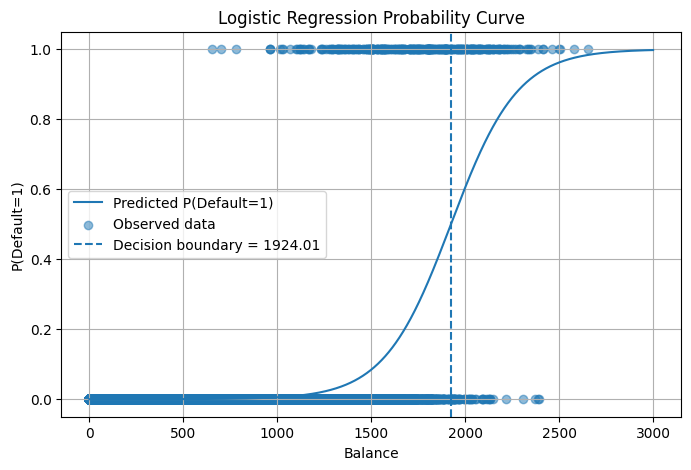

In [44]:
# Your code:

# prob = model.predict_proba(X[["balance"]])[:,1]

data = pd.DataFrame({"balance": np.arange(0, 3001)})
data["probability"] = model.predict_proba(
    data[["balance"]]
)[:,1]

intercept = model.intercept_[0]
coefficient = model.coef_[0][0]
decision_boundary = -intercept / coefficient


plt.figure(figsize=(8,5))


# sigmoid probability curve
plt.plot(
    data["balance"],
    data["probability"],
    label="Predicted P(Default=1)"
)


# observed data points
plt.scatter(
    df["balance"],
    df["default"],
    alpha=0.5,
    label="Observed data"
)


# decision boundary
plt.axvline(
    decision_boundary,
    linestyle="--",
    label=f"Decision boundary = {decision_boundary:.2f}"
)


plt.xlabel("Balance")

plt.ylabel("P(Default=1)")

plt.title("Logistic Regression Probability Curve")

plt.legend()

plt.grid()

plt.show()

## 6. Evaluate on held-out test data


Use the fitted model to obtain:

- hard class predictions;
- positive-class probability scores;
- accuracy;
- F1 score;
- MCC;
- confusion matrix.

Display the confusion matrix with readable class labels.

**Hints:**

- `model.predict(X_test)` returns 0/1 predictions.
- `model.predict_proba(X_test)[:, 1]` returns scores for `default=1`.
- Use the metric functions imported above to compute accuracy, f1, and mcc: `accuracy_score`, `f1_score`, `matthews_corrcoef`
- Use `confusion_matrix` and `ConfusionMatrixDisplay` to count and display the matrix with color


Accuracy: 0.9716666666666667 

F1 score: 0.4370860927152318 

matthews_corrcoef: 0.44961844470034085 

confusion_matrix: 
 [[2882   18]
 [  67   33]]


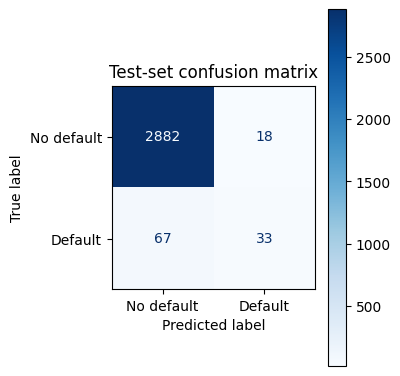

In [45]:
# Your code:

y_pred = model.predict(X_test[['balance']])
y_scores = model.predict_proba(X_test[['balance']])[:,1]

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}", '\n')

f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1}", '\n')

corrcoef = matthews_corrcoef(y_test, y_pred)
print(f"matthews_corrcoef: {corrcoef}", '\n')

con_matrix = confusion_matrix(y_test, y_pred)
print(f"confusion_matrix: \n {con_matrix}")


matrix = ConfusionMatrixDisplay(confusion_matrix=con_matrix, display_labels=["No default", "Default"])
fig, ax = plt.subplots(figsize=(4,4))
matrix.plot(ax=ax, cmap='Blues')
plt.tight_layout()
plt.title("Test-set confusion matrix")
plt.show()

### Think about it

1. how many actual defaults were detected and missed;
      33 were detected, 67 were missed.

2. why accuracy alone may give an overly optimistic impression.
      Because the data is highly imbalanced.


## 7. Compare with the always-negative baseline


Create a baseline that predicts `0` for every test observation. Calculate accuracy, F1, MCC, and the confusion matrix for the baseline, then compare it with the logistic model.

Present your final results in a small table with rows for:

- always-negative baseline;
- logistic regression.

Use columns for Accuracy, F1, and MCC. Include both confusion matrices below the table.


**Important:** create a new array for the baseline using `np.zeros_like()`


In [46]:
# Your code:

baseline = np.zeros_like(y_pred)

base_acc = accuracy_score(y_test, baseline)
base_f1 = accuracy_score(y_test, baseline)
base_mcc = matthews_corrcoef(y_test, baseline)
 
print(f"\t\t Accuracy\t\t F1\t\t\t MCC")
print(f"baseline\t {base_acc} \t {base_f1} \t {base_mcc}")
print(f"logistic \t {acc} \t {f1} \t {corrcoef}")


print("\n\nConfusion matrix:")
base_cm = confusion_matrix(y_test, baseline)
print(base_cm, "\n")
print(con_matrix)

		 Accuracy		 F1			 MCC
baseline	 0.9666666666666667 	 0.9666666666666667 	 0.0
logistic 	 0.9716666666666667 	 0.4370860927152318 	 0.44961844470034085


Confusion matrix:
[[2900    0]
 [ 100    0]] 

[[2882   18]
 [  67   33]]


<div style="background-color: #f0f8ff; padding: 10px; border-radius: 5px;">
  <h3 style="color: #0056b3;">Assessment Questions (10 points, 1-point each)</h3>

Each question has only 1 correct answer.
Record your answers as `1 A, 2 B, ...` in the space below, one row for each.
</div>


<div style="background-color: #FEF7E0 ; padding: 10px; border-radius: 5px;">
    
# Your answers:
1 B  
2 B   
3 D   
4 A  
5 C  
6 B  
7 A  
8 C  
9 B  
10 D
</div>

## Conceptual Questions: 10 points

Choose one answer for each question. Each question is worth 1 point.

1. Which mapping correctly converts the target labels?

   A. `{"No": 1, "Yes": 0}`  
   B. `{"No": 0, "Yes": 1}`  
   C. `{"No": -1, "Yes": 1}`  
   D. `{"No": 1, "Yes": 1}`

2. Why is `df[["balance"]]` used instead of `df["balance"]` when creating `X`?

   A. It sorts the balance values.  
   B. It returns a two-dimensional table suitable for scikit-learn.  
   C. It converts balance into probabilities.  
   D. It removes missing values automatically.

3. Why should the train/test split be performed before fitting the model?

   A. To make the model converge faster.  
   B. To increase the number of observations.  
   C. To force the coefficient to be positive.  
   D. To prevent data leakage and ensure the model is evaluated on unseen data.  

4. What is the purpose of `stratify=y` in `train_test_split`?

   A. It preserves the class proportions in both partitions.  
   B. It standardizes the feature values.  
   C. It removes the minority class.  
   D. It selects the best random seed.

5. What does `model.fit(X_train, y_train)` do?

   A. It evaluates the model on the test set.  
   B. It changes the target labels into strings.  
   C. It estimates the model parameters from the training data.  
   D. It plots the ROC curve.

6. What does `model.predict_proba(X_test)[:, 1]` provide?

   A. The predicted class labels for class 0.  
   B. The probability score for the positive class.  
   C. The model coefficient for balance.  
   D. The probability score for the negative class.  

7. For the one-feature model, why is the 0.5 decision boundary calculated as `-intercept / coefficient`?

   A. The sigmoid probability is 0.5 when the linear score is zero.  
   B. The coefficient is always equal to the accuracy.  
   C. The intercept is the average balance.  
   D. ROC-AUC is defined by this formula.

8. In `confusion_matrix(y_test, y_pred)`, what does the entry at row 1, column 0 represent?

   A. True positive: actual default, predicted default.  
   B. False positive: actual no default, predicted default.  
   C. False negative: actual default, predicted no default.  
   D. True negative: actual no default, predicted no default.

9. How many actual defaulters were correct identified?

   A. 18.  
   B. 33.  
   C. 67.  
   D. 2882.

9. Why can the always-negative baseline have high accuracy but F1 and MCC equal to zero?

   A. It predicts every case correctly.  
   B. It has too many positive predictions.  
   C. It uses predicted probabilities instead of labels.  
   D. It benefits from class imbalance but detects no positive cases.  

   


~~ This is the end ~~